# Modelo de oferta de crédito

# Incorporando os pacotes requisitados

In [ ]:
!pip install jupyter-dash
!pip install dexplot


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
from jupyter_dash import JupyterDash
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import auc, roc_curve, roc_auc_score, plot_roc_curve, f1_score, plot_confusion_matrix, classification_report
from imblearn.under_sampling import RandomUnderSampler
import xgboost as xgb
import dash_core_components as dcc
import dash_html_components as html
from dash.dependencies import Input, Output
import pandas as pd #Para lidar com a base de dados
import numpy as np #Biblioteca matemática
import seaborn as sns #Biblioteca de gráficos
import matplotlib.pyplot as plt #Para complementar os gráficos
plt.style.use('classic')
%matplotlib inline
import plotly.offline as py
import plotly.graph_objs as go #
import plotly.subplots as psub #
import plotly.tools as tls #
import warnings #
from collections import Counter #

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:6: UserWarning: 
The dash_core_components package is deprecated. Please replace
`import dash_core_components as dcc` with `from dash import dcc`
  
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:7: UserWarning: 
The dash_html_components package is deprecated. Please replace
`import dash_html_components as html` with `from dash import html`
  import sys


# Coletando os dados

In [ ]:
raw_data = pd.read_csv('/content/Loan_status_2007-2020Q3.gzip', low_memory=False)# puxando os dados

In [ ]:
'max_bal_bc' in raw_data.columns

True

In [ ]:
raw_data = raw_data[raw_data['loan_status'].isin(['Fully Paid', 'Charged Off', 'Default'])]
# realizando as devidas correções
raw_data['int_rate'] = raw_data['int_rate'].str.rstrip('%').astype('float')#convertendo int_rate para o tipo float
raw_data['year'] = pd.to_datetime(raw_data['issue_d']).dt.year

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
raw_data.head(20)

,Unnamed: 0,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag,year
0,0,1077501,5000.0,5000.0,4975.0,36 months,10.65,162.87,B,B2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,2011
1,1,1077430,2500.0,2500.0,2500.0,60 months,15.27,59.83,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,2011
2,2,1077175,2400.0,2400.0,2400.0,36 months,15.96,84.33,C,C5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,2011
3,3,1076863,10000.0,10000.0,10000.0,36 months,13.49,339.31,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,2011
4,4,1075358,3000.0,3000.0,3000.0,60 months,12.69,67.79,B,B5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,2011
5,5,1075269,5000.0,5000.0,5000.0,36 months,7.90,156.46,A,A4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,2011
6,6,1069639,7000.0,7000.0,7000.0,60 months,15.96,170.08,C,C5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,2011
7,7,1072053,3000.0,3000.0,3000.0,36 months,18.64,109.43,E,E1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,2011
8,8,1071795,5600.0,5600.0,5600.0,60 months,21.28,152.39,F,F2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,2011
9,9,1071570,5375.0,5375.0,5350.0,60 months,12.69,121.45,B,B5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,2011


# Análise exploratória dos dados

##### Temos a seguir um gráfico de barras, em que o eixo x é a frequencia de ocorrencia e o eixo y as razões que fizeram o individuo não pagar

[Text(0.5, 1.0, 'Principais razões por não pagar')]

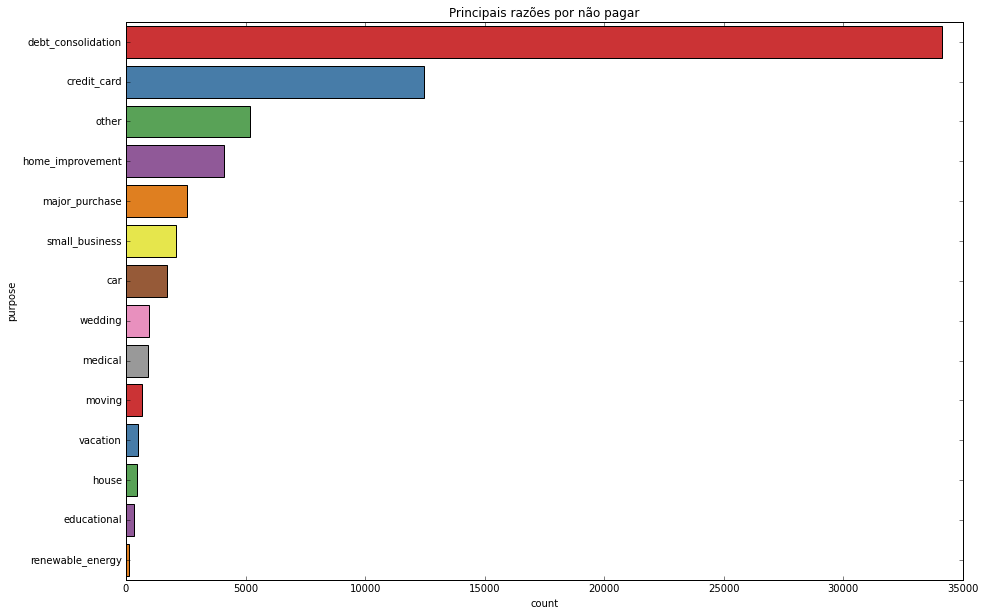

In [ ]:
plt.figure(figsize=(15,10))
ax = sns.countplot(y="purpose", data=raw_data, palette="Set1",
                   order=raw_data['purpose'].value_counts().index,
                   dodge=False)
(ax.set(title="Principais razões por não pagar"))


#### A seguir, um gráfico contendo o número de emprestimos realizados por estado norte americano

In [ ]:
statewise_loan_freq = raw_data.groupby(['addr_state'], as_index=False).size()# Agrupando por estado

In [ ]:
fig = go.Figure(
    data=go.Choropleth(
        locations=list(statewise_loan_freq['addr_state'].values),
        z = list(statewise_loan_freq['size'].values),
        locationmode = 'USA-states',
        colorscale = 'cividis'
))

fig.update_layout(
    title_text = 'Número de emprestimos por estado',
    geo_scope='usa',
)

fig.show()

#### O próximo gráfico remete à distribuição de probabilidade da váriaveil divida/renda

[Text(0.5, 1.0, 'Função de densidade de probabilidade para a variavel divida/renda')]

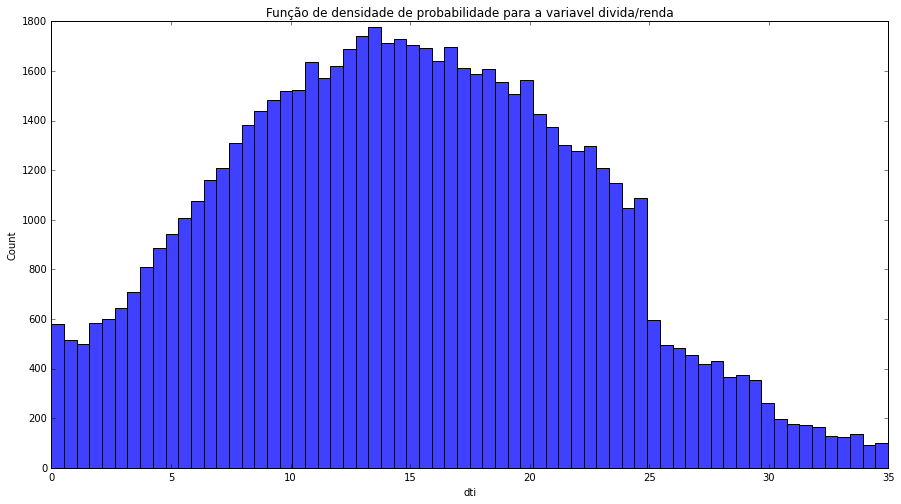

In [ ]:
dti_non_null = raw_data[~raw_data['dti'].isnull()]#retirando as variaveis que são nulas

plt.figure(figsize=(15, 8))
ax = sns.histplot(x="dti", data=dti_non_null)
ax.set(title="Função de densidade de probabilidade para a variavel divida/renda")

#### Percebemos que esta variável é fortemente assimétrica, uma vez essa variável aletória é sempre posiva. Além disso, existem muitos outliers.

#### A seguir, uma sequencia de box-plots caracterizando as distribuições do montante que foi emprestado por ano

[Text(0.5, 1.0, 'Distribuição do montante creditada por ano')]

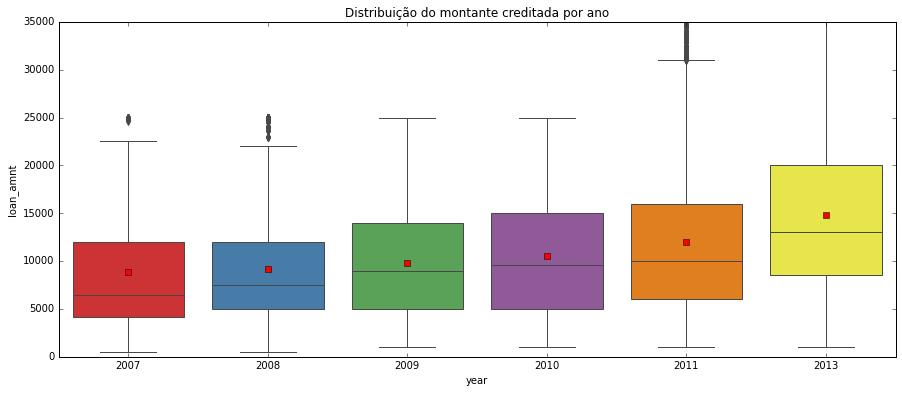

In [ ]:
plt.figure(figsize=(15, 6))
ax = sns.boxplot(x="year", y="loan_amnt", palette="Set1",
                 data=raw_data[raw_data['year'] != 2020], showmeans=True)
ax.set(title="Distribuição do montante creditada por ano")

#### Percebemos um aumento progressivo da média e mediana do montante emprestado, que finda no ano de 2013. A partir daí, a distribuição da quantidade de crédito ofertada aparenta estar centrada em valores próximos.

# Regressão logistica, XG boosting.

## Pacotes e funções

In [ ]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score # para separar os dados
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, fbeta_score #para avaliar os modelos
from sklearn.model_selection import GridSearchCV # selecionar as variaveis
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression# modelo de regressão logistica
from sklearn import preprocessing #preprocessamento
import numpy as np#biblioteca matematica
from sklearn.utils import resample # amostra
from sklearn.metrics import roc_curve# curva para vaaliar o modelo

## Pré processamento

In [ ]:
raw_data = raw_data[raw_data['verification_status'].isin(['Verified', 'Source Verified'])]#selecionando os dados verificados

In [ ]:
raw_data['default'] = raw_data['loan_status'].map({'Fully Paid':0,'Charged Off':1, 'Default':1})#criando variavel alvo

In [ ]:
row_count = len(raw_data)
na_count = raw_data.isnull().sum()
l = []
for col_name, count in na_count.iteritems():
    l.append([col_name, count, int((count/row_count) * 100)])

na_df = pd.DataFrame(columns=['col_name', 'count', 'percent'], data = l)# faz df com o nome  da coluna, o núemro de nas e a porcentagem de nas.

In [ ]:
pd.set_option('display.max_rows', 500)

In [ ]:
raw_data.drop(na_df[na_df.percent >= 90].col_name.to_list(), axis=1, inplace=True)# retira as variaveis com mais de 5% de NA

In [ ]:
remove = ['hardship_flag', 'total_bc_limit', 'Unnamed: 0'] # Variaveis para remover


In [ ]:
fill_with_0s = ['max_bal_bc', 'mort_acc', 'mths_since_last_major_derog', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'inq_fi', 'inq_last_12m', 'inq_last_6mths', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'chargeoff_within_12_mths', 'collections_12_mths_ex_med', 'open_rv_12m', 'open_rv_24m', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bal_il', 'total_il_high_credit_limit', 'total_rev_hi_lim', 'total_cu_tl']

In [ ]:
fill_with_neg1 = ['mths_since_last_delinq', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'revol_util', 'tax_liens', 'tot_coll_amt', 'tot_cur_bal', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mths_since_last_record', 'mths_since_rcnt_il', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 'mths_since_recent_revol_delinq']

In [ ]:
raw_data.drop(remove, axis=1, inplace=True)

In [ ]:
for col in fill_with_0s:
    raw_data[col].fillna(0, inplace=True)

KeyError: ignored

In [ ]:
for col in fill_with_neg1:
    raw_data[col].fillna(-1, inplace=True)

In [ ]:
# Variaveis que serão consideradas no modelo
keep = ['year',
 'avg_cur_bal',
 'default',
 'fico',
 'loan_amnt',
 'term',
 'int_rate',
 'installment',
 'sub_grade',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'purpose',
 'addr_state',
 'dti',
 'earliest_cr_line',
 'inq_last_6mths',
 'open_acc',
 'pub_rec',
 'initial_list_status',
 'mths_since_last_major_derog',
 'application_type',
 'acc_now_delinq',
 'tot_cur_bal',
 'open_acc_6m',
 'open_act_il',
 'open_il_12m',
 'mths_since_rcnt_il',
 'total_bal_il',
 'open_rv_12m',
 'max_bal_bc',
 'total_cu_tl',
 'mo_sin_old_il_acct',
 'mo_sin_old_rev_tl_op',
 'mo_sin_rcnt_rev_tl_op',
 'mo_sin_rcnt_tl',
 'mort_acc',
 'mths_since_recent_bc',
 'mths_since_recent_revol_delinq',
 'num_actv_rev_tl',
 'num_il_tl',
 'pct_tl_nvr_dlq',
 'pub_rec_bankruptcies']

In [ ]:
#### corrigindo  casos especificos

raw_data['emp_length'].fillna('< 1 year', inplace=True)
raw_data['emp_title'].fillna('', inplace=True)
raw_data['last_credit_pull_d'].fillna('', inplace=True)
raw_data['last_pymnt_d'].fillna('', inplace=True)
raw_data['title'].fillna('', inplace=True)
raw_data['zip_code'].fillna('xxxxx', inplace=True)

In [ ]:
raw_data = raw_data.set_index(['id'], drop=True)

In [ ]:
drop_cols = set(raw_data.columns.to_list()) - set(keep)

In [ ]:
raw_data.drop(drop_cols, axis=1, inplace=True)

In [ ]:
emp_len_map = {
    '10+ years' : 10,
    '< 1 year' : 0,
    '1 year' : 1,
    '3 years' : 3,
    '9 years' : 9,
    '4 years' : 4,
    '2 years' : 2,
    '7 years' : 7,
    '5 years' : 5,
    '6 years' : 6,
    '8 years' : 8
}

In [ ]:
# mudando prazo do emprestimo para inteiro
raw_data['emp_length'] = raw_data.apply(lambda r: emp_len_map[r.emp_length], axis=1)

In [ ]:
# tirtando o mês
raw_data['earliest_cr_line']  = raw_data.apply(lambda r: int(r['earliest_cr_line'][-4:]), axis=1)
raw_datafinal=raw_data

In [ ]:

#### codificação one hoting


for feature, prefix in zip(['term', 'purpose', 'sub_grade'],
                           ['TERM', 'PURPOSE', 'SUB_GRADE']):
    dummy = pd.get_dummies(raw_data[feature], prefix=prefix, drop_first=True)
    raw_data = pd.concat([raw_data, dummy], axis=1)
    raw_data = raw_data.drop(feature, axis=1)

In [ ]:
# codificando rotulos
label_encoder = LabelEncoder()

for feature in ['home_ownership', 'addr_state', 'initial_list_status', 'application_type']:
    raw_data[feature]= label_encoder.fit_transform(raw_data[feature])

In [ ]:
# Fabricando nova variavel: nova variavel.
raw_data['monthly_load'] = raw_data.apply(
    lambda r: ((r.installment * 12) / r.annual_inc) * 100 if r.annual_inc != 0 else -1,
    axis=1)

### Verificando assimetria das variaveis

In [ ]:
plt.figure(figsize=(15, 8))
ax = sns.distplot(a=raw_datafinal.annual_inc,hist=False)
ax.set(title="Função de densidade de probabilidade para a variavel renda anual")

In [ ]:

plt.figure(figsize=(15, 8))
ax = sns.histplot(x="open_acc", data=raw_datafinal)
ax.set(title="Função de densidade de probabilidade para a variavel número de ilhas de crédito abertas pela conta")

In [ ]:
# Transformando variaveis que são muito assimetricas

raw_data['annual_inc'] = np.log(raw_data['annual_inc'] + 1)
raw_data['open_acc'] = np.log(raw_data['open_acc'] + 1)

### É importante frizar que o preechimento dos dados faltantes com sua mediana só pode ser realizado depois da divisão dos sets de dado, para não ocorrer vazamento de informação.

In [ ]:
# dividindo nos sets de treino e teste(antes de imputar as variaveus faltantes, para não ter vazamento de informação)
X = raw_data.drop('default', axis=1)
y = raw_data['default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1)

In [ ]:
#imputando variaveis faltantes
X_train['dti'].fillna(X_train['dti'].median(), inplace=True)

### Dado que existe uma diferença muito grande entre o numero de pagantes e não pagantes, foi interessante balancear o banco de dados. Dessa forma, o modelo pode ser melhor adequado.

In [ ]:
# Lidando com o desbalanceamento do banco de dados
ros = RandomUnderSampler(random_state=1)
X_train_new, y_train_new = ros.fit_resample(X_train, y_train)

## Adequando o modelo

In [ ]:
dmatrix = xgb.DMatrix(data=X_train_new, label=y_train_new, feature_names=X.columns.to_list()) ### aqui colocamos os dados no formato certo, para utilizar no pacote xgb

In [ ]:
### treinando o modelo com todas as variaveis.

xgb_trained = xgb.train(params={'objective':"reg:logistic",
                                'seed':1},
                        dtrain=dmatrix)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
xgb.plot_importance(xgb_trained, ax=ax)

### performance do modelo com todas as variáveis.

In [ ]:
model = xgb.XGBClassifier(objective="reg:logistic", seed=1, use_label_encoder=False)
model.fit(X_train_new, y_train_new)
y_pred = model.predict(X_test)


accuracy = roc_auc_score(y_test, y_pred)
print("ROC AUC Score: %.2f%%" % (accuracy * 100.0))


print(classification_report(y_test, y_pred))

In [ ]:

# Retirando variaveis com menor impacto
drop_cols = list(set(raw_data.columns) -
                 set(['year', 'monthly_load',
                      'int_rate', 'avg_cur_bal',  'TERM 60 months', 'fico',
                      'dti', 'mo_sin_old_rev_tl_op', 'annual_inc', 'emp_length', 'num_actv_rev_tl',
                      'home_ownership']))

In [ ]:
# divididno em set de treino e teste novamente
X = raw_data.drop(drop_cols, axis=1)
y = raw_data['default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1)

In [ ]:
X_train['dti'].fillna(X_train['dti'].median(), inplace=True)

In [ ]:
# Handling class imbalance by undersampling.
ros = RandomUnderSampler(random_state=1)
X_train_new, y_train_new = ros.fit_resample(X_train, y_train)

In [ ]:
model = xgb.XGBClassifier(objective="reg:logistic", seed=1, use_label_encoder=False)
model.fit(X_train_new, y_train_new)
y_pred = model.predict(X_test)

### vemos que a performance cai muito pouco, mesmo retirando diversas variáveis.
### Quando isso ocorre, opta-se por retirar as variáveis com pouco impacto, uma vez que reduz possíveis vieses.


### Agora vamos avaliar as métricas do modelo escolhido

In [ ]:
accuracy = roc_auc_score(y_test, y_pred)
print("ROC AUC Score: %.2f%%" % (accuracy * 100.0))

In [ ]:
print(classification_report(y_test, y_pred))

In [ ]:
plot_confusion_matrix(model, X_test, y_test)

In [ ]:
fpr1, tpr1, threshold1 = roc_curve(y_test, y_pred)
roc_auc1 = auc(fpr1, tpr1)

In [ ]:
y_pred_train = model.predict(X_train_new)
fpr2, tpr2, threshold2 = roc_curve(y_train_new, y_pred_train)
roc_auc2 = auc(fpr2, tpr2)

In [ ]:
plt.figure(figsize=(10, 8))

plt.title('Receiver Operating Characteristic')
plt.plot(fpr1, tpr1, 'b', label = 'AUC Test = %0.2f' % roc_auc1)
plt.plot(fpr2, tpr2, 'g', label = 'AUC Train = %0.2f' % roc_auc2)

plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')

plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

### Percebemos que o modelo ficou bem adequado

### Agora vamos definir as categorias dos indivíduos, elaborando nosso modelo de escolha de oferta de taxa de juros.

In [ ]:
lr_preds = model.predict_proba(X)
lr_preds_df = pd.DataFrame(lr_preds[:,1][0:], columns = ['lr_pred_PD'])
lr_preds_df
raw_dataSFinal=pd.concat([raw_datafinal.reset_index(drop = True), lr_preds_df], axis = 1)

In [ ]:
raw_dataSFinal['ScoreCredito']= (raw_dataSFinal['lr_pred_PD'])*1000
raw_dataSFinal['ScoreCredito']



In [ ]:
intervalo = (175, 225, 350, 475, 600, 725, 825, 900)# dividindo os intervalos de score de crédito

cats = ['A', 'B', 'C', 'D','E','F','G']# categorias de scor de crédito
raw_dataSFinal["Categoria"] = pd.cut(raw_dataSFinal.ScoreCredito, intervalo, labels=cats)

## Resultados

###Aqui percebemos claramente que a média e mediana de taxa de juros cresce na medida que as categorias estabelecidas pelo nosso modelo vão de A até G

In [ ]:
plt.figure(figsize=(15, 10))
ax = sns.boxplot(x="Categoria", y="int_rate", palette="Set1",
                 order = ['A', 'B', 'C', 'D', 'E', 'F', 'G'],
                 data=raw_dataSFinal)
ax.set(title="A taxa de juros cresce na mediade em que a categoria de crédtio do individuo muda.")
plt.legend(loc='lower right')

### Aqui caracterizamos visualmente a distribuição da razão valor do empréstimo e renda.

In [ ]:
plt.figure(figsize=(20,15))
ax = sns.boxplot(x="Categoria", y="dti", palette="Set1",
                 order = ['A', 'B', 'C', 'D', 'E', 'F', 'G'],
                 data=raw_dataSFinal)
ax.set(title="Númeor de vezes em que  adivida supera a renda por categoria")
plt.legend(loc='lower right')

### Percebemos que as categorias de extremidade possuem menor variabilidade, no que tange ao número de vezes que o empréstimo supera a renda. Isso ocorre, muito provavelmente, no caso da categoria A, ao fato de que, para ter um bom score de crédito, é necessário que o indivíduo não deva muitas vezes o que ganha. E, para a categoria G, isso se deve pela dificuldade que esses indivíduos têm de conseguir crédito.


### Agora, vamos checar como são as diferenças dos grupos no que tange a situação de moradia.

In [ ]:
import dexplot as dxp
df = raw_dataSFinal
dxp.count('Categoria', data=df, split="home_ownership", normalize='Categoria')



### Aqui percebemos que os indivíduos com acesso a melhores taxas de juros são aqueles que oferecem sua casa como hipoteca. Sendo assim uma característica então, dos grupos mais bem classificados.

### Agora caracterizamos os diferentes tipos de aplicação, se é conjunta ou individual, entre os grupos que definimos no modelo

In [ ]:
df = raw_dataSFinal
dxp.count('Categoria', data=df, split="application_type", normalize='Categoria')


### Percebemos que indivíduos em categorias com melhor score de crédito geralmente fazem aplicações individuais.